# PU experiments

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [10]:
EXPERIMENT = "c"

In [11]:
df = load_experiment_results(name=EXPERIMENT,n=0)
df = df[df["model"]!="oracle"]
# df["model"] = "classic"
df

,c,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support,c log
0,0.01,mock,0,classic,0.600000,0.600000,0.000000,1.000000,0.000000,0.750000,0.000000,195,130,NaN
1,0.01,mock,0,naive,0.400000,0.000000,0.400000,0.000000,1.000000,0.000000,0.571429,195,130,NaN
3,0.01,mock,0,two_model,0.600000,0.600000,0.000000,1.000000,0.000000,0.750000,0.000000,195,130,NaN
4,0.01,mock,1,classic,0.600000,0.600000,0.000000,1.000000,0.000000,0.750000,0.000000,195,130,NaN
5,0.01,mock,1,naive,0.400000,0.000000,0.400000,0.000000,1.000000,0.000000,0.571429,195,130,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1913,1.00,mnist,8,naive,0.964196,0.966292,0.962016,0.963585,0.964835,0.964937,0.963424,1428,1365,NaN
1915,1.00,mnist,8,two_model,0.957035,0.964489,0.949458,0.950980,0.963370,0.957687,0.956364,1428,1365,NaN
1916,1.00,mnist,9,classic,0.968135,0.967855,0.968429,0.969888,0.966300,0.968870,0.967363,1428,1365,NaN
1917,1.00,mnist,9,naive,0.970641,0.973277,0.967907,0.969188,0.972161,0.971228,0.970029,1428,1365,NaN


In [12]:
def remove_failed_experiments(df):
    """Remove failed experiments from the dataframe."""
    idx = df.loc[(df["0 precision"]==0) | (df["0 recall"]==0) | (df["1 precision"]==0) | (df["1 recall"]==0)].index
    return df.drop(index=idx)

print("Before removing failed experiments:", df.shape)
df = remove_failed_experiments(df)
print("After removing failed experiments:", df.shape)


Before removing failed experiments: (1440, 14)
After removing failed experiments: (1156, 14)


In [13]:
# df_old = load_experiment_results(name=EXPERIMENT,n=1)
# df_old = df_old[(df_old["model"]!="oracle") & (df_old["model"]!="classic")] 
# df_old = df_old[(df_old["dataset"]=="mnist")] 
# df = pd.concat([df_old,df],axis=0)
# df

In [14]:
# df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
# df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
# df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df["f1"] = df["1 f1"]
df["precision"] = df["1 precision"]
df["recall"] = df["1 recall"]

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4)
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,1156.000000,1156.000000,1156.000000
mean,0.827223,0.708001,0.697082
std,0.202405,0.306754,0.271749
min,0.066700,0.000700,0.001400
25%,0.639350,0.521100,0.577725
50%,0.950100,0.823800,0.735100
75%,0.985950,0.953800,0.940525
max,1.000000,1.000000,1.000000


In [15]:
fig_experiment_folder = EXPERIMENT
os.makedirs(os.path.join("output", fig_experiment_folder), exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [19]:
df.model.unique()

array(['two_model', 'naive', 'classic'], dtype=object)

In [20]:
df["model"].rename({"two_model":"Two Model","naive":"Naive","classic":"Classic"},inplace=True)

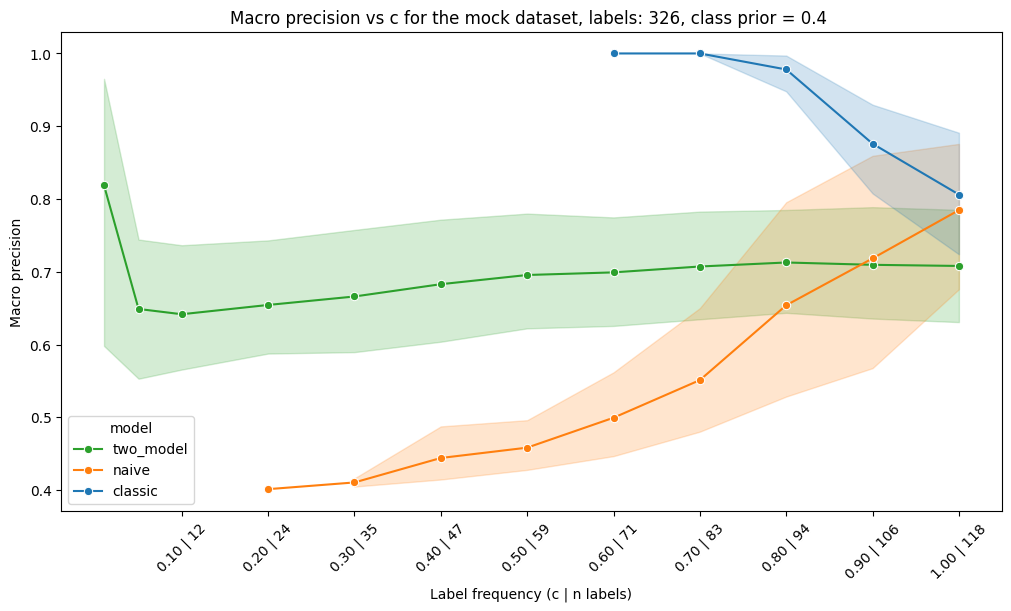

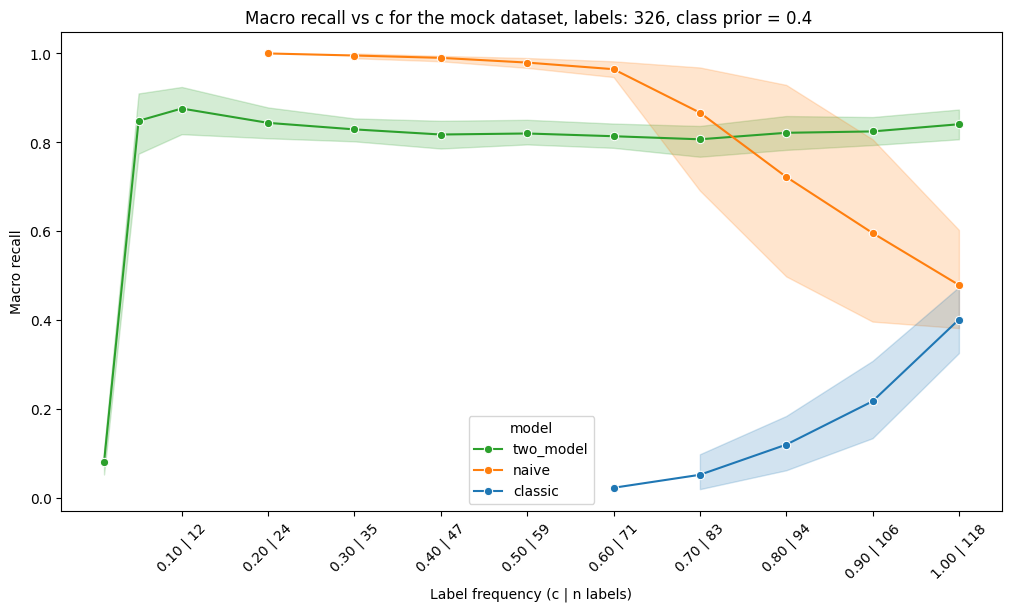

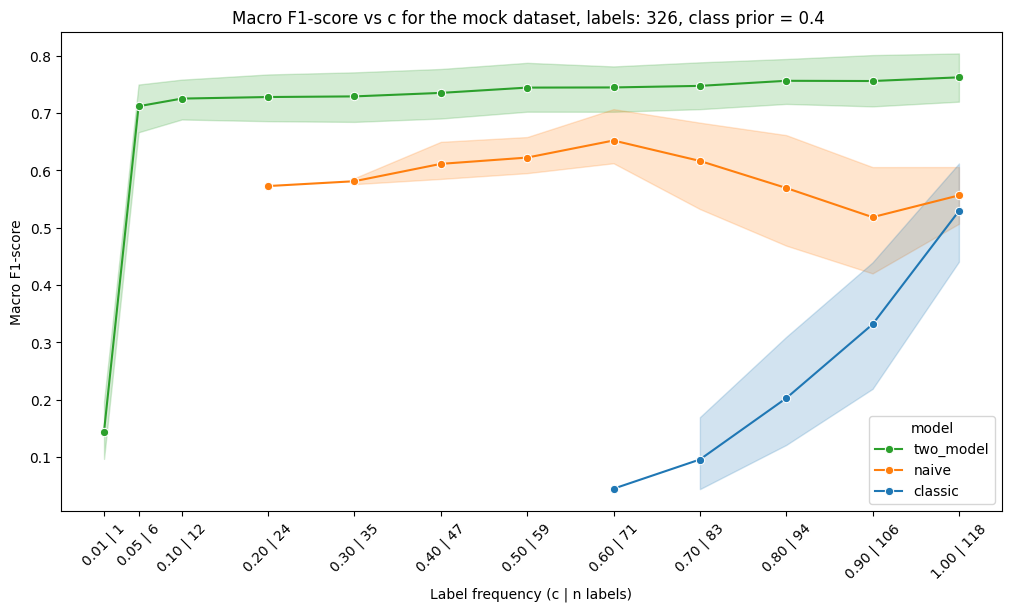

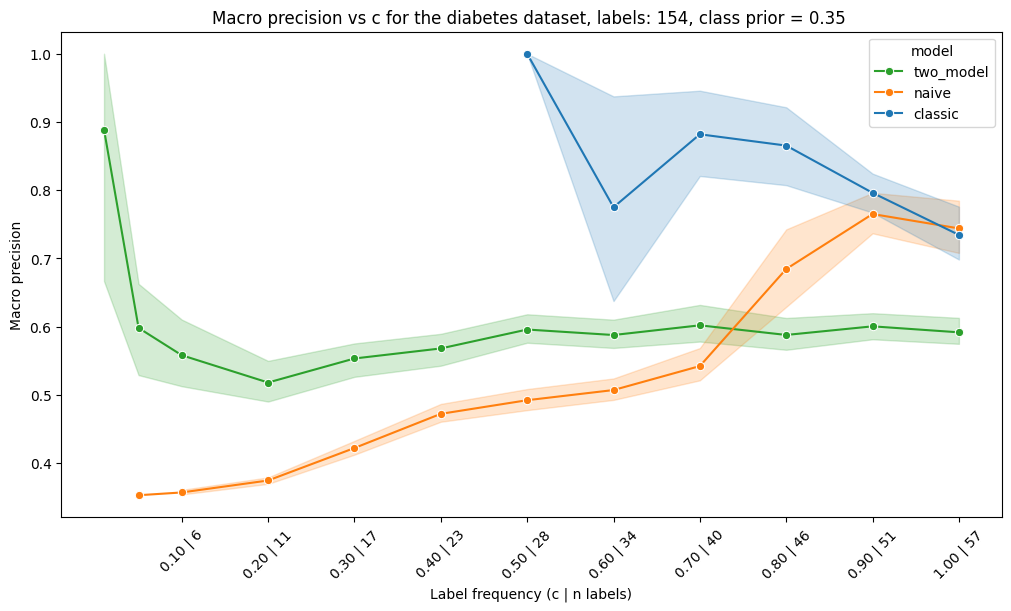

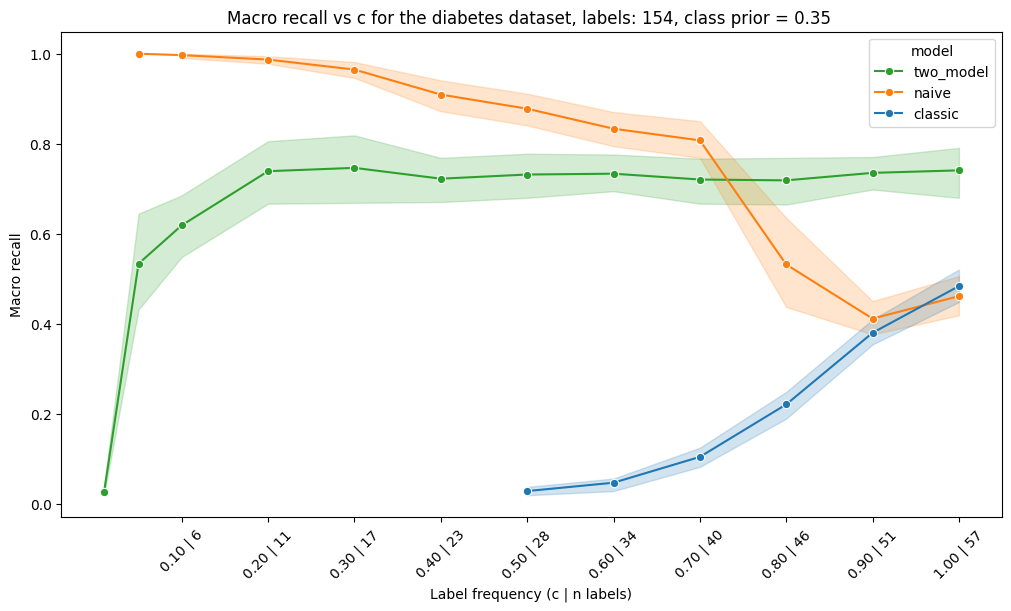

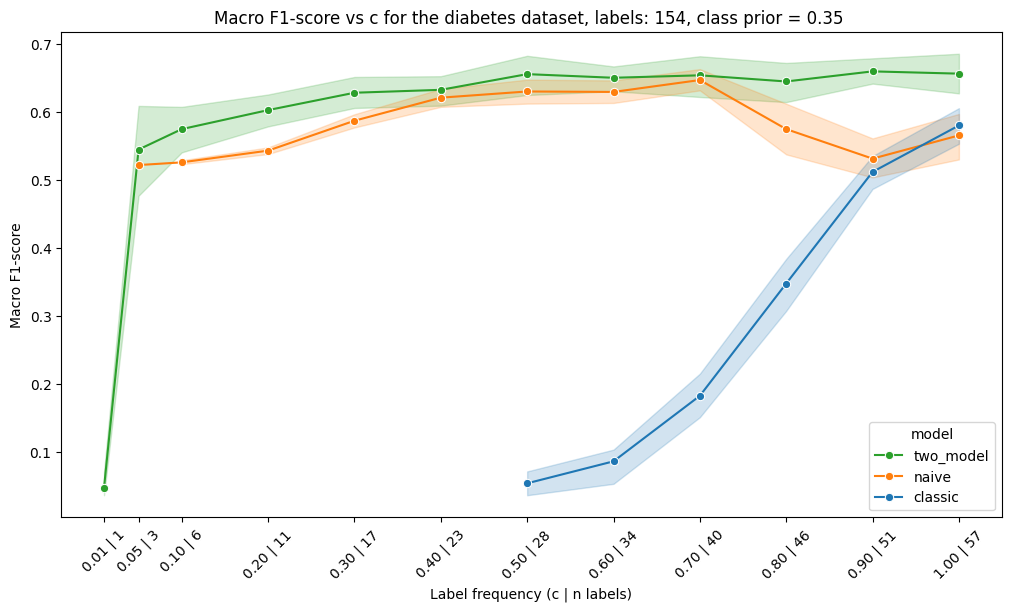

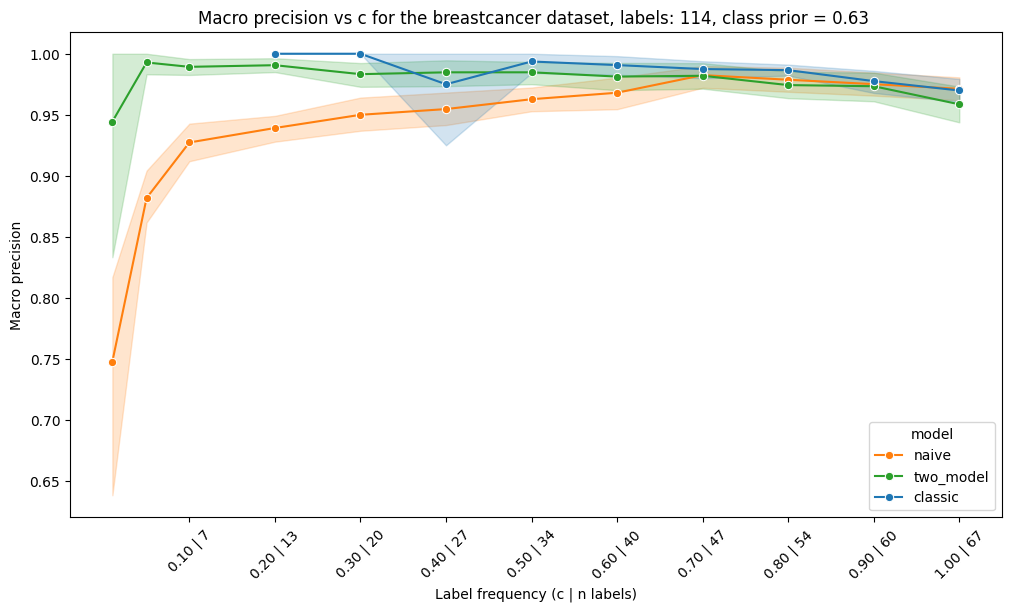

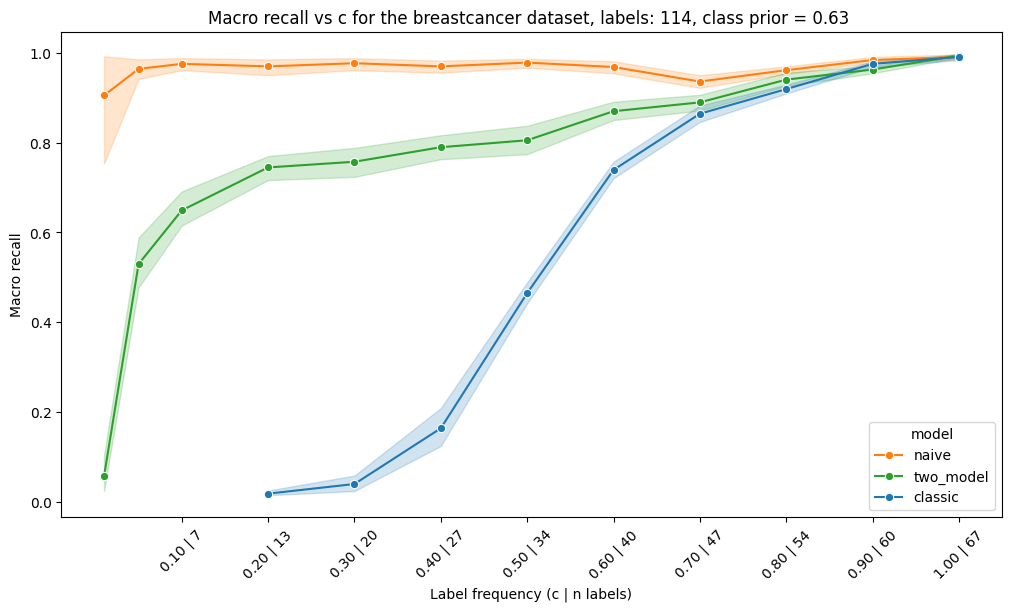

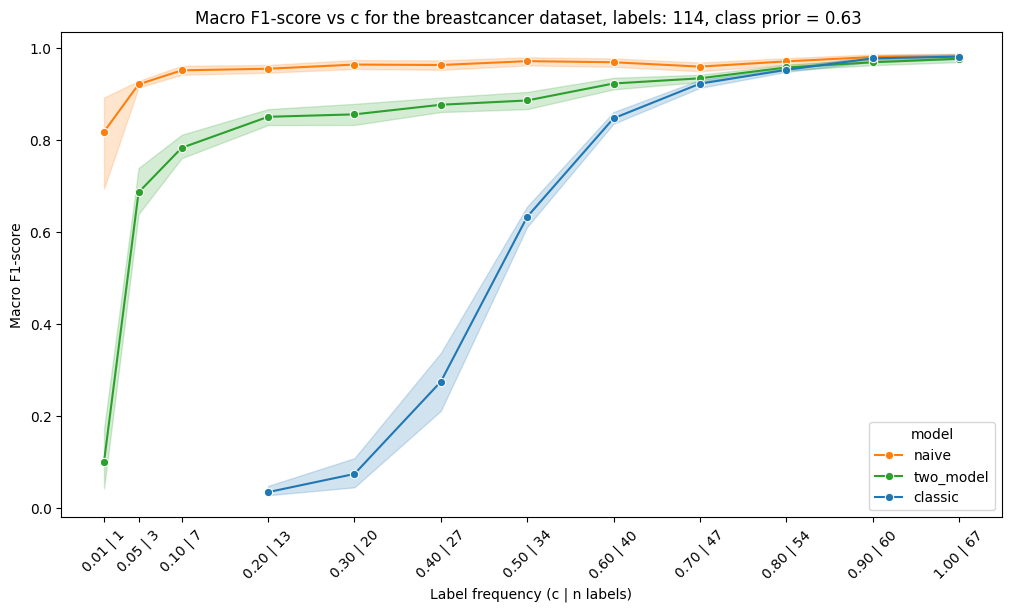

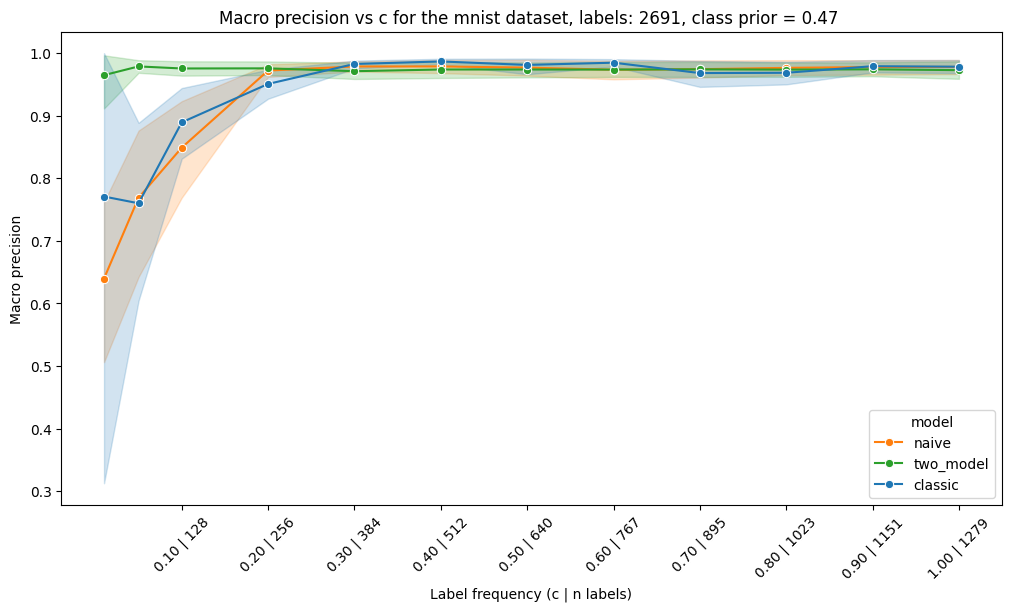

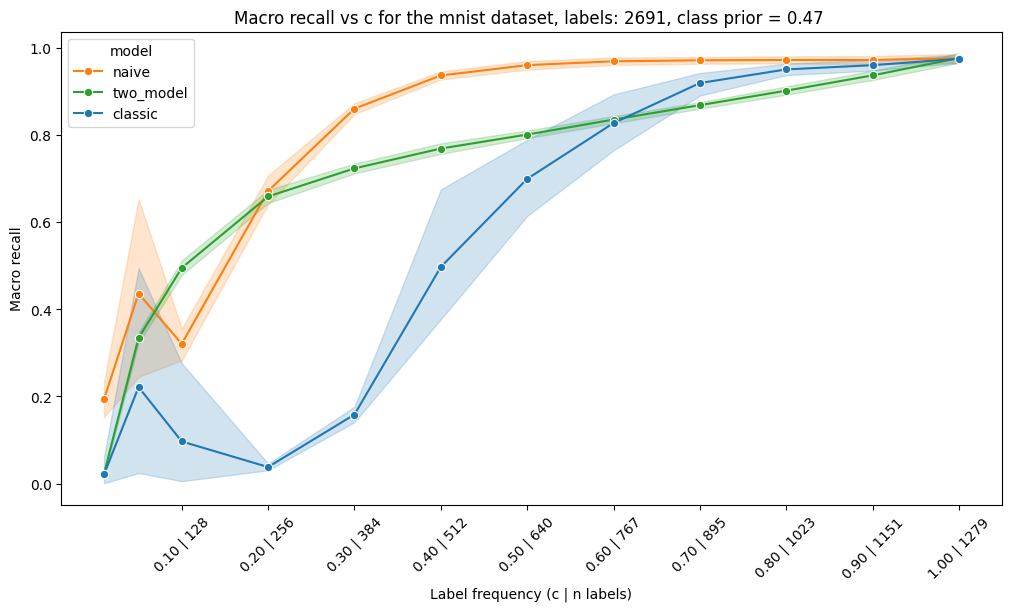

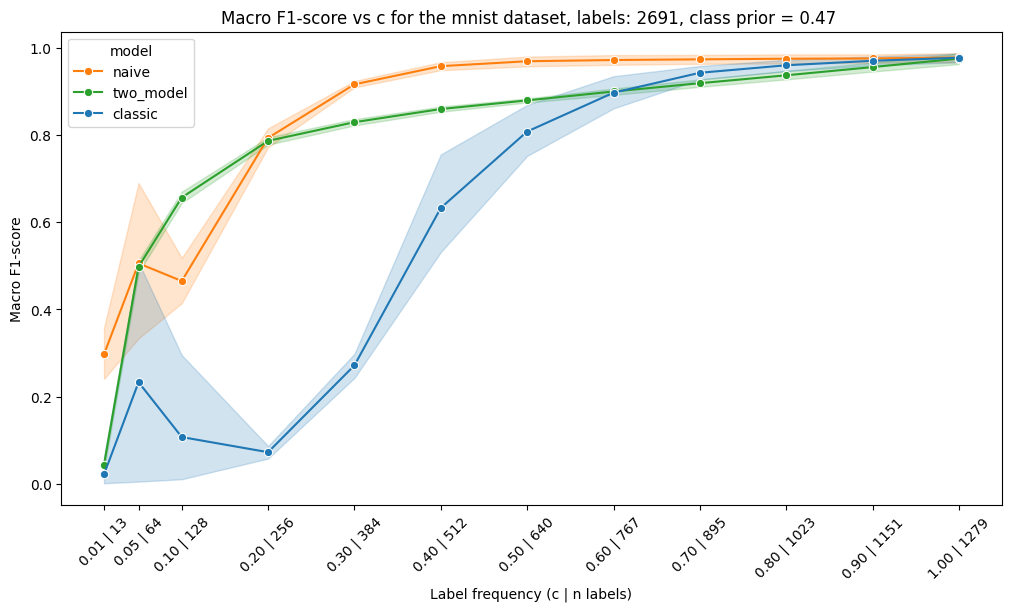

In [24]:

for dataset in df["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], f"Unknown dataset: {dataset}"
    c = df["c"].unique().tolist()
    n_labels = get_n_labels(dataset, df["c"].unique())
    ticks = [n_labels[val] for val in c]
    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="precision",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2"})
    plt.title(f"Macro precision vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro precision")
    plt.xticks(c[2:], ticks[2:],rotation=45)

    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"Precision_macro_{dataset}.png"))
    plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="recall",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2"})
    plt.title(f"Macro recall vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro recall")
    plt.xticks(c[2:], ticks[2:],rotation=45)
    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"Recall_macro_{dataset}.png"))
    plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="f1",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2"})
    plt.title(f"Macro F1-score vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Macro F1-score")
    plt.xticks(c, ticks,rotation=45)
    plt.xlabel("Label frequency (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"F1_1_{dataset}.png"))
    plt.show()
